# rio-tiler tests

In [31]:
from rio_tiler.io import Reader
import morecantile
import matplotlib.pyplot as plt

In [22]:
src_path = "./tci.tif"

In [23]:
with Reader(src_path) as image:
    print(image.dataset)  # rasterio opened dataset
    img = image.read()    # similar to rasterio.open("my.tif").read() but returns a rio_tiler.models.ImageData object

<open DatasetReader name='./tci.tif' mode='r'>


In [25]:
with Reader(src_path) as image:
    # img = image.tile(x, y, z)            # read mercator tile z-x-y
    # img = image.part(bbox)               # read the data intersecting a bounding box
    # img = image.feature(geojson_feature) # read the data intersecting a geojson feature
    
    # get pixel values for a lon/lat coordinates
    print(image.point(-1.797016, 49.629957))
    print(image.point(586873.83, 5498202.54, coord_crs=image.crs))           

PointData(data=array([20, 64, 17], dtype=uint8), mask=array([255], dtype=uint8), band_names=['b1', 'b2', 'b3'], coordinates=(-1.797016, 49.629957), crs=CRS.from_epsg(4326), assets=['./tci.tif'], metadata={})
PointData(data=array([21, 65, 17], dtype=uint8), mask=array([255], dtype=uint8), band_names=['b1', 'b2', 'b3'], coordinates=(586873.83, 5498202.54), crs=CRS.from_epsg(32630), assets=['./tci.tif'], metadata={})


In [26]:
with Reader(src_path) as src:
    print(f"Bounds in dataset CRS: {src.bounds}")
    print(f"Bounds WGS84: {src.geographic_bounds}")
    print(f"MinZoom (WebMercator): {src.minzoom}")
    print(f"MaxZoom (WebMercator): {src.maxzoom}")

Bounds in dataset CRS: (499980.0, 5490240.0, 609780.0, 5600040.0)
Bounds WGS84: (-3.0002823155078517, 49.55480005680557, -1.4506718532732477, 50.55229211014782)
MinZoom (WebMercator): 7
MaxZoom (WebMercator): 13


In [53]:
# rio-tiler defaults to the WebMercator Grids. The grid definition is provided by the morecantile module
# Docs: https://github.com/developmentseed/morecantile
tms = morecantile.tms.get("WebMercatorQuad")
print(repr(tms))

# Get the list of tiles for the COG minzoom 
with Reader(src_path) as cog:
    tile_cover = list(tms.tiles(*cog.geographic_bounds, zooms=9))

print(f"Nb of Z{cog.minzoom} Mercator tiles: {len(tile_cover)}")
print(tile_cover)

<TileMatrixSet title='Google Maps Compatible for the World' identifier='WebMercatorQuad'>
Nb of Z7 Mercator tiles: 9
[Tile(x=251, y=172, z=9), Tile(x=251, y=173, z=9), Tile(x=251, y=174, z=9), Tile(x=252, y=172, z=9), Tile(x=252, y=173, z=9), Tile(x=252, y=174, z=9), Tile(x=253, y=172, z=9), Tile(x=253, y=173, z=9), Tile(x=253, y=174, z=9)]


In [54]:
with Reader(src_path) as src:
    images = [src.tile(*tile) for tile in tile_cover]
    print([img.data.shape for img in images])

[(3, 256, 256), (3, 256, 256), (3, 256, 256), (3, 256, 256), (3, 256, 256), (3, 256, 256), (3, 256, 256), (3, 256, 256), (3, 256, 256)]


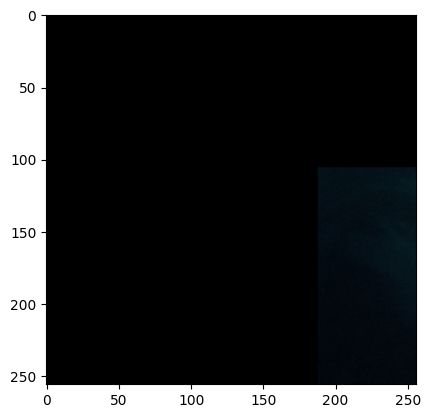

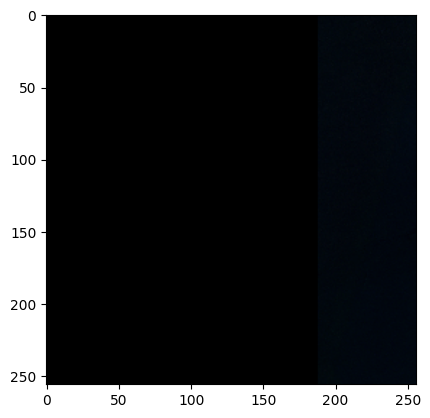

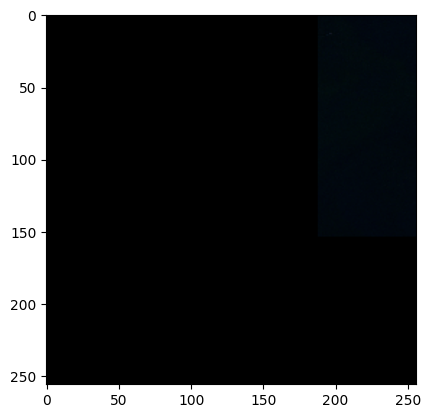

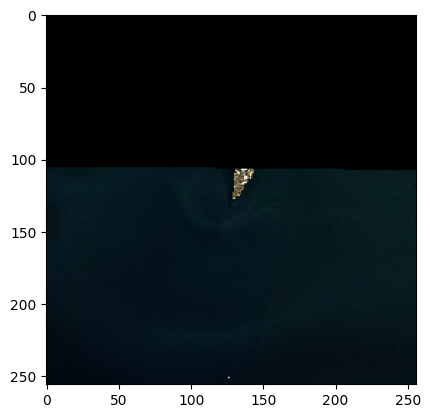

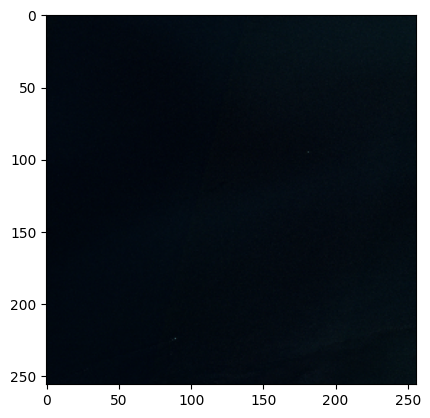

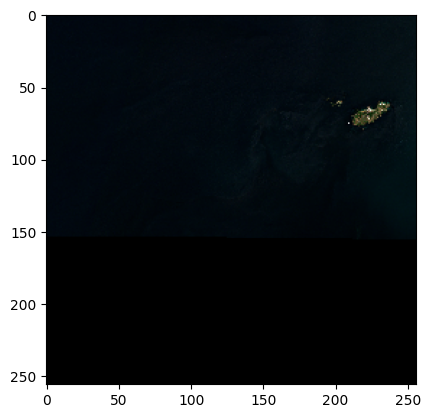

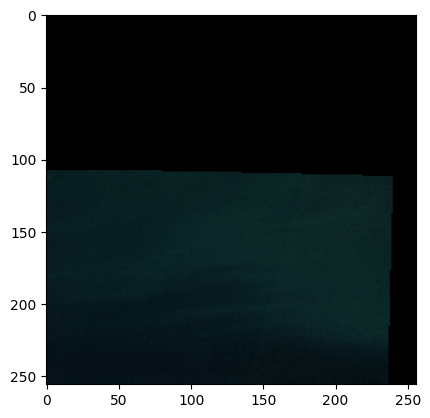

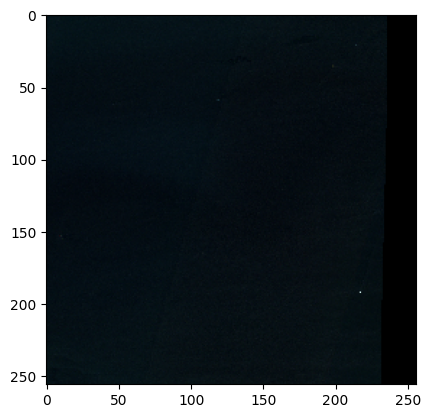

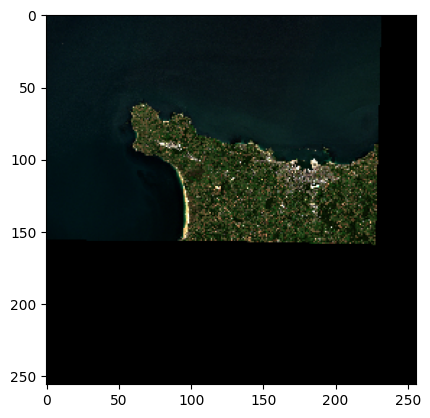

In [55]:
for img in images:
    plt.figure()
    plt.imshow(img.data_as_image())